<a href="https://colab.research.google.com/github/JuanPabloCardona2311/Lab-1-Vision-Por-Computador/blob/main/Reto1_Matrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generar matriz

In [ ]:
import random

def crear_matriz(filas, columnas):
    return [[random.randint(0, 255) for _ in range(columnas)] for _ in range(filas)]

matriz = crear_matriz(1000, 1000)

Estadisticas

In [ ]:
def estadisticas_manual(matriz):
    filas = len(matriz)
    columnas = len(matriz[0])
    n = filas * columnas

    minimo = matriz[0][0]
    maximo = matriz[0][0]
    suma = 0

    # Primera pasada: mínimo, máximo y suma (para la media)
    for fila in matriz:
        for pixel in fila:
            if pixel < minimo:
                minimo = pixel
            if pixel > maximo:
                maximo = pixel
            suma += pixel

    media = suma / n

    # Segunda pasada: suma de cuadrados (para la desviación estándar)
    suma_cuadrados = 0
    for fila in matriz:
        for pixel in fila:
            suma_cuadrados += (pixel - media) ** 2

    varianza = suma_cuadrados / n
    desviacion = varianza ** 0.5

    return minimo, maximo, media, desviacion

Medir tiempos

In [ ]:
import time

inicio = time.time()

matriz = crear_matriz(1000, 1000)
minimo, maximo, media, desviacion = estadisticas_manual(matriz)

fin = time.time()
tiempo_manual = fin - inicio

print(f"Tiempo (sin librerías): {tiempo_manual:.4f} segundos")
print(f"Min: {minimo}, Max: {maximo}, Media: {media:.2f}, Desv. Est.: {desviacion:.2f}")

Tiempo (sin librerías): 1.4638 segundos
Min: 0, Max: 255, Media: 127.53, Desv. Est.: 73.92


Aplanar la matriz

In [ ]:
def aplanar(matriz):
    return [pixel for fila in matriz for pixel in fila]

vector = aplanar(matriz)

Guardar la matriz

In [ ]:
with open('matriz.csv', 'w') as f:
    for valor in vector:
        f.write(f"{valor}\n")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta = '/content/drive/MyDrive/Lab1 VisionIA/matriz.csv'

Estadisticas con numPy

In [ ]:
import numpy as np
import time

inicio2 = time.time()

vector_np = np.loadtxt(ruta, dtype=np.uint8)

minimo_np = np.min(vector_np)
maximo_np = np.max(vector_np)
media_np = np.mean(vector_np)
desviacion_np = np.std(vector_np)

fin2 = time.time()
tiempo_numpy = fin2 - inicio2

print(f"Tiempo (con NumPy): {tiempo_numpy:.4f} segundos")
print(f"Min: {minimo_np}, Max: {maximo_np}, Media: {media_np:.2f}, Desv. Est.: {desviacion_np:.2f}")

Tiempo (con NumPy): 0.4221 segundos
Min: 0, Max: 255, Media: 127.53, Desv. Est.: 73.92


In [ ]:
print("la diferencia entre los tiempos fue de: ")
print(f"Método manual: {tiempo_manual:.4f} s")
print(f"Método NumPy:  {tiempo_numpy:.4f} s")
print(f"NumPy fue {tiempo_manual/tiempo_numpy:.1f}x más rápido")

la diferencia entre los tiempos fue de: 
Método manual: 1.4638 s
Método NumPy:  0.4221 s
NumPy fue 3.5x más rápido


Reconstruir y mostrar la imagen

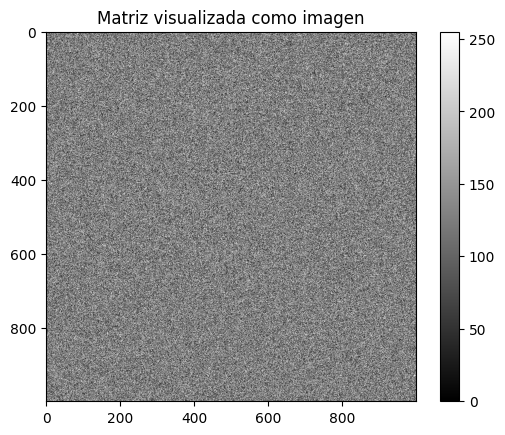

In [ ]:
import matplotlib.pyplot as plt

imagen = vector_np.reshape(1000, 1000)

plt.imshow(imagen, cmap='gray')
plt.title('Matriz visualizada como imagen')
plt.colorbar()
plt.show()

Mostrar con openCV

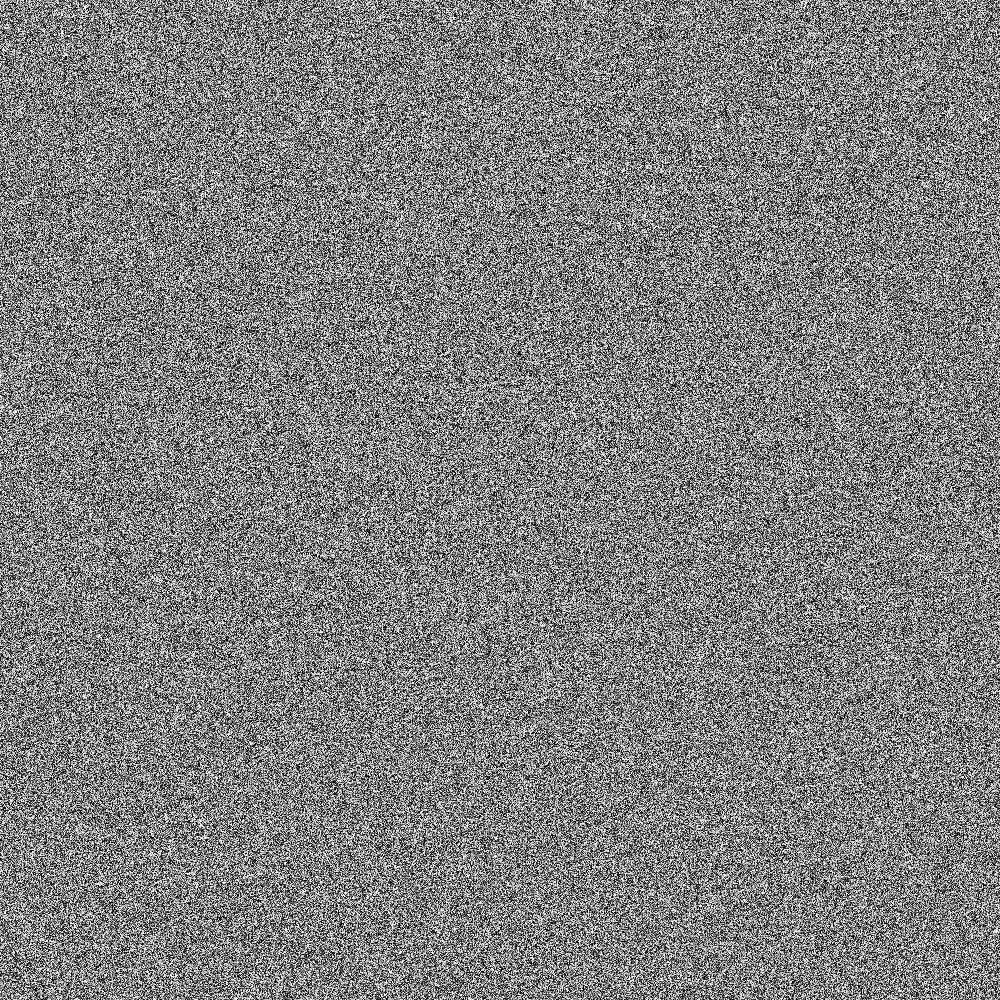

In [ ]:
from google.colab.patches import cv2_imshow
import cv2

imagen = vector_np.reshape(1000, 1000)

cv2_imshow(imagen)

## Análisis de Resultados y Conclusiones

**Comparación de estadísticas (manual vs. NumPy)**

Al calcular el mínimo, máximo, media y desviación estándar con el método manual
(recorriendo la matriz con bucles de Python puro) y luego con NumPy, los resultados
fueron [iguales / prácticamente iguales, con una diferencia mínima de redondeo en
la desviación estándar de aproximadamente [73.92]]. Esto confirma que ambas
implementaciones son matemáticamente equivalentes: la diferencia entre ellas no
está en el resultado, sino en cómo se calcula internamente.

**Comparación de tiempos de ejecución**

El método manual tardó [1.4638] segundos, mientras que el método con NumPy tardó [0.4221]
segundos — es decir, NumPy fue aproximadamente [3.5x] veces más rápido.

**Sobre la visualización de la imagen**

Al reconstruir el vector aplanado en una matriz de 1000x1000 y visualizarlo como
imagen, el resultado se ve como ruido o estática (similar a una televisión sin
señal), sin ningún patrón, forma o estructura reconocible. Esto es el
comportamiento esperado, ya que los valores de la matriz se generaron de forma
completamente aleatoria e independiente entre sí — no existe ninguna correlación
espacial entre píxeles vecinos, que es justamente lo que le da a una imagen real
su apariencia de "objeto reconocible" (bordes continuos, áreas de color uniforme,
gradientes suaves).

**Sobre el flujo completo (creación → guardado → Drive → lectura → análisis)**

El proceso de guardar el archivo localmente, subirlo a Google Drive, y volver a
leerlo desde Colab permitió comprobar que los datos se conservan intactos a
través de todo el flujo: las estadísticas obtenidas en la segunda etapa
(con NumPy, tras leer desde Drive) coincidieron con las obtenidas en la primera
etapa (manualmente, sobre la matriz recién creada). Esto confirma que el archivo
de texto plano es un formato de intercambio confiable para este tipo de datos,
aunque no es el más eficiente en espacio: cada valor ocupa varios caracteres
como texto (por ejemplo "255\n"), mientras que en una imagen real (como un
.png o .jpg) cada píxel puede representarse en un solo byte, o incluso menos
gracias a la compresión.

**Conclusión general**

Este ejercicio permitió comprobar en la práctica por qué, más allá de que sea
posible implementar operaciones matriciales "a mano" en Python puro, las
librerías especializadas como NumPy son el estándar en visión por computador:
ofrecen resultados idénticos con una ganancia de rendimiento significativa,
lo cual es crítico cuando se trabaja con imágenes reales (que fácilmente superan
los millones de píxeles) o con conjuntos de datos de muchas imágenes a la vez,
como ocurre en aplicaciones de machine learning.